[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
100%|██████████████████████████████████████████████████████████████████████████| 49614/49614 [00:16<00:00, 3017.57it/s]


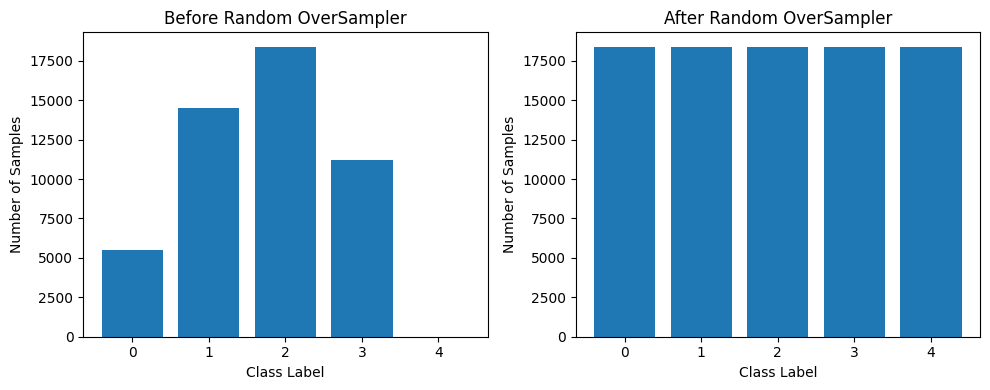

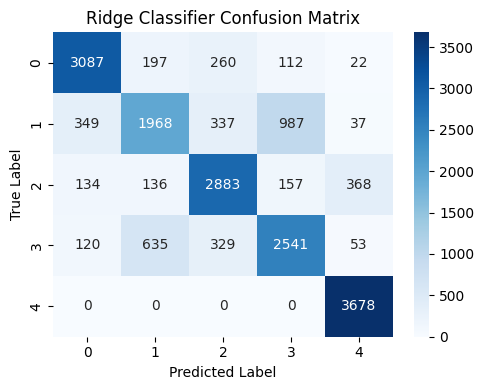

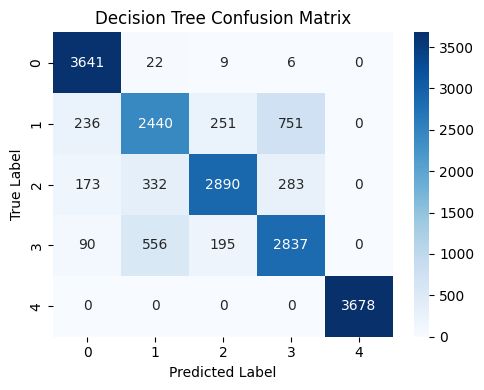

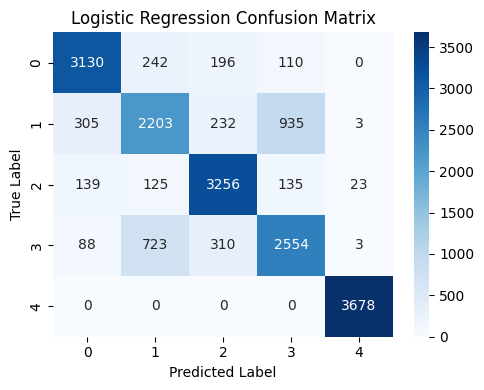

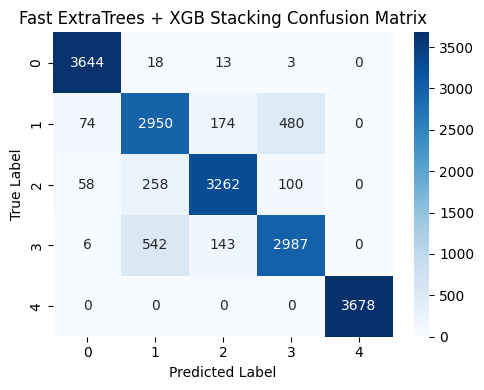

In [1]:
from tkinter import *
import tkinter
from tkinter import filedialog
from tkinter.filedialog import askopenfilename
from tkinter import simpledialog
# ---------------------------
# Core Libraries
# ---------------------------
import os
import re
import string
import joblib
import numpy as np
import pandas as pd

# ---------------------------
# Visualization
# ---------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.special import expit  # sigmoid
# ---------------------------
# NLP Libraries
# ---------------------------
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.util import ngrams
from wordcloud import WordCloud

# ---------------------------
# Machine Learning
# ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report   
)

from sklearn.preprocessing import label_binarize

# ---------------------------
# Utilities
# ---------------------------
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import os
from sklearn.tree import DecisionTreeClassifier
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import joblib
import os
import joblib
import os
from PIL import Image, ImageTk


global MODEL_DIR, RESULT_DIR, categories, y, stop_words, lemmatizer

Accuracy_list = []
Precision_list = []
Recall_list = []
F1_list = []
cls_names = []
AUC_list = []

def clearText():
    text.delete('1.0', END)


MODEL_DIR = "models"
RESULT_DIR = "results"


os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
tqdm.pandas()

def uploadDataset():
    clearText()
    global df
    filename = filedialog.askopenfilename(initialdir = "Df")
    text.delete('1.0', END)
    text.insert(END,filename+' Loaded\n')
    df = pd.read_csv(filename)
    text.insert(END,str(df.head())+"\n\n")


def eda_nlp_analysis(X_text, num_words=100, top_n_words=20):
    """
    Perform NLP EDA:
        1. WordCloud
        2. Top N words
        3. Document length histogram
        4. POS tag frequency
        5. Bigram frequency

    Parameters:
        X_text (list of str): Input preprocessed text data.
        num_words (int): Number of words to show in word cloud.
        top_n_words (int): Number of top frequent words to plot.
    """
    print("Generating NLP EDA Visualizations...")

    # Flatten all tokens from all texts
    all_tokens = [word for doc in X_text for word in word_tokenize(doc)]

    # --- 1. WordCloud ---
    word_freq = Counter(all_tokens)
    wc = WordCloud(width=800, height=400, max_words=num_words, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top {num_words} Words - WordCloud")
    plt.show()

    # --- 2. Top-N Frequent Words ---
    common_words = word_freq.most_common(top_n_words)
    words, counts = zip(*common_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title(f"Top {top_n_words} Most Frequent Words")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

    # --- 3. Document Length Histogram ---
    doc_lengths = [len(word_tokenize(doc)) for doc in X_text]
    plt.figure(figsize=(10, 5))
    sns.histplot(doc_lengths, bins=20, kde=True, color='teal')
    plt.title("Distribution of Document Lengths (in words)")
    plt.xlabel("Number of Words per Document")
    plt.ylabel("Frequency")
    plt.show()

    # --- 4. POS Tag Frequency ---
    all_pos = [tag for _, tag in pos_tag(all_tokens)]
    pos_counts = Counter(all_pos).most_common()
    pos_tags, pos_freqs = zip(*pos_counts)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")
    plt.title("Part of Speech (POS) Tag Frequency")
    plt.xlabel("POS Tag")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

    # --- 5. Bigram Frequency Plot ---
    bigrams = list(ngrams(all_tokens, 2))
    bigram_freq = Counter(bigrams).most_common(top_n_words)
    bigram_labels = [' '.join(b) for b, _ in bigram_freq]
    bigram_counts = [count for _, count in bigram_freq]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")
    plt.title(f"Top {top_n_words} Bigrams")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.show()

def run_eda():
    clearText()
    global df
    df["text"] = df["text"].fillna("").astype(str)
    eda_nlp_analysis(X_text=df["text"], num_words=100, top_n_words=20)
    text.insert(END,"EDA Applied Successfully")

def preprocess_text_full(text):

    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9' ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = word_tokenize(text)

    pos_tags = pos_tag(tokens)

    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return wordnet.ADJ
        elif tag.startswith('V'):
            return wordnet.VERB
        elif tag.startswith('N'):
            return wordnet.NOUN
        elif tag.startswith('R'):
            return wordnet.ADV
        return wordnet.NOUN

    lemmas = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
        if word not in stop_words and word.strip() != ""
    ]

    return " ".join(lemmas)

def Preprocess():
    clearText()
    global df
    df["clean_text"] = df["text"].progress_apply(preprocess_text_full)
    text.insert(END, "Pre-processing completed")
    text.insert(END,str(df.head())+"\n\n")

def extract_text_features(text):
    tokens = text.split()

    if len(tokens) == 0:
        return pd.Series([0]*10)

    return pd.Series([
        len(tokens),
        len(text),
        np.mean([len(w) for w in tokens]),
        np.std([len(w) for w in tokens]),
        sum(w.isupper() for w in tokens),
        sum(any(c.isdigit() for c in w) for w in tokens),
        sum(w.isalpha() for w in tokens),
        len(set(tokens)),
        len(set(tokens)) / len(tokens),
        sum(len(w) > 6 for w in tokens)
    ])

def generate_stat_features():
    clearText()
    global df, stat_features

    if "clean_text" not in df.columns:
        text.insert(END, "Please run preprocessing first\n")
        return

    stat_features = df["clean_text"].progress_apply(extract_text_features)

    stat_features.columns = [
        "word_count","char_count","avg_word_len","std_word_len",
        "upper_words","digit_words","alpha_words",
        "unique_words","lexical_diversity","long_words"
    ]
    
    text.insert(END,"Statistical features generated successfully\n")
    text.insert(END,str(stat_features.head())+"\n\n")

def apply_vectorization():
    clearText()
    global df, X_text, y, vectorizer, le

    if "clean_text" not in df.columns:
        text.insert(END, "Please run preprocessing first\n")
        return

    if "status" not in df.columns:
        text.insert(END, "Dataset must contain 'status' column\n")
        return

    text.insert(END, "Applying Label Encoding + TF-IDF...\n")

    # Label Encoding target
    le = LabelEncoder()
    y = le.fit_transform(df['status'])

    # TF-IDF Vectorizer
    vectorizer = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=3
    )

    X_text = vectorizer.fit_transform(df["clean_text"])

    text.insert(END, f"Vectorization Complete\n")
    text.insert(END, f"Feature Matrix Shape: {X_text.shape}\n")
    text.insert(END, f"Classes: {list(le.classes_)}\n\n")

def apply_svd_scaling():
    clearText()
    global X_text, stat_features, X_final, svd, stdscaler

    if 'X_text' not in globals():
        text.insert(END, "Please run Vectorization first\n")
        return

    if 'stat_features' not in globals():
        text.insert(END, "Please generate statistical features first\n")
        return

    text.insert(END, "Applying SVD + Scaling + Feature Fusion...\n")

    # SVD
    svd = TruncatedSVD(n_components=300, random_state=42)
    X_text_svd = svd.fit_transform(X_text)

    # Scaling
    stdscaler = StandardScaler()
    X_text_svd = stdscaler.fit_transform(X_text_svd)

    # Combine features
    X_final = np.hstack([
        X_text_svd,
        stat_features.values
    ])

    text.insert(END, "Feature Fusion Completed\n")
    text.insert(END, f"Final Feature Shape: {X_final.shape}\n\n")



def apply_random_oversampling():
    clearText()
    global X_final, y, X_balanced, y_balanced

    if 'X_final' not in globals():
        text.insert(END, "Please run SVD + Merge step first\n")
        return

    text.insert(END, "Applying Random OverSampler...\n")

    ros = RandomOverSampler(random_state=42)
    X_balanced, y_balanced = ros.fit_resample(X_final, y)

    # Counts before
    y_before = pd.Series(y)
    before_counts = y_before.value_counts().sort_index()

    # Counts after
    y_after = pd.Series(y_balanced)
    after_counts = y_after.value_counts().sort_index()

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].bar(before_counts.index.astype(str), before_counts.values)
    axes[0].set_title("Before Random OverSampler")
    axes[0].set_xlabel("Class Label")
    axes[0].set_ylabel("Number of Samples")

    axes[1].bar(after_counts.index.astype(str), after_counts.values)
    axes[1].set_title("After Random OverSampler")
    axes[1].set_xlabel("Class Label")
    axes[1].set_ylabel("Number of Samples")

    plt.tight_layout()
    plt.show()

    text.insert(END, "Oversampling Completed\n")
    text.insert(END, f"Balanced Shape: {X_balanced.shape}\n\n")

def split_dataset():
    clearText()
    global X_train, X_test, y_train, y_test

    if 'X_balanced' not in globals() or 'y_balanced' not in globals():
        text.insert(END,"Please generate balanced dataset first\n")
        return

    text.insert(END,"Splitting dataset...\n")

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced,
        y_balanced,
        test_size=0.2,
        random_state=42,
        stratify=y_balanced
    )

    text.insert(END,f"Train Shape: {X_train.shape}\n")
    text.insert(END,f"Test Shape: {X_test.shape}\n\n")

def calculateMetrics(name, preds, y_test):

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted")
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    try:
        y_bin = label_binarize(y_test, classes=np.unique(y_test))
        p_bin = label_binarize(preds, classes=np.unique(y_test))
        auc = roc_auc_score(y_bin, p_bin, average="weighted", multi_class="ovr")
    except:
        auc = 0.0

    cls_names.append(name)
    Accuracy_list.append(acc)
    Precision_list.append(prec)
    Recall_list.append(rec)
    F1_list.append(f1)
    AUC_list.append(auc)

    report = classification_report(y_test, preds)

    text.insert(END, f"\n{name} Results\n")
    text.insert(END, "-----------------------------------\n")
    text.insert(END, f"Accuracy  : {acc:.4f}\n")
    text.insert(END, f"Precision : {prec:.4f}\n")
    text.insert(END, f"Recall    : {rec:.4f}\n")
    text.insert(END, f"F1 Score  : {f1:.4f}\n")
    text.insert(END, f"AUC Score : {auc:.4f}\n\n")
    text.insert(END, report + "\n")

    # ----- CONFUSION MATRIX -----
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


def plot_classification_comparison():

    if len(cls_names) == 0:
        text.insert(END, "Train models first!\n")
        return

    x = np.arange(len(cls_names))
    width = 0.15

    plt.figure(figsize=(14,6))

    bars1 = plt.bar(x - 2*width, Accuracy_list, width, label="Accuracy")
    bars2 = plt.bar(x - width, Precision_list, width, label="Precision")
    bars3 = plt.bar(x, Recall_list, width, label="Recall")
    bars4 = plt.bar(x + width, F1_list, width, label="F1")
    bars5 = plt.bar(x + 2*width, AUC_list, width, label="AUC")

    def add_labels(bars):
        for bar in bars:
            h = bar.get_height()
            plt.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.2f}",
                     ha="center", fontsize=8)

    for b in [bars1,bars2,bars3,bars4,bars5]:
        add_labels(b)

    plt.xticks(x, cls_names, rotation=20)
    plt.title("Model Performance Comparison")
    plt.ylabel("Score")
    plt.ylim(0,1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

def train_ridge():
    clearText()
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    ridge_model = RidgeClassifier(random_state=42)
    ridge_model.fit(X_train_scaled, y_train)
    
    joblib.dump(ridge_model, os.path.join(MODEL_DIR, "ridge_classifier.pkl"))
    
    y_pred_ridge = ridge_model.predict(X_test_scaled)
    
    calculateMetrics("Ridge Classifier", y_pred_ridge, y_test)

def train_decision():
    clearText()

    # Decision Trees do NOT require feature scaling
    dt_model = DecisionTreeClassifier(random_state=42)
    
    dt_model.fit(X_train, y_train)
    
    joblib.dump(dt_model, os.path.join(MODEL_DIR, "decision_tree.pkl"))
    
    y_pred_dt = dt_model.predict(X_test)
    
    calculateMetrics("Decision Tree", y_pred_dt, y_test)

def train_log():
    clearText()

    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    log_model = LogisticRegression(random_state=42, max_iter=1000)
    
    log_model.fit(X_train_scaled, y_train)
    
    joblib.dump(log_model, os.path.join(MODEL_DIR, "logistic_regression.pkl"))
    
    y_pred_log = log_model.predict(X_test_scaled)
    
    calculateMetrics("Logistic Regression", y_pred_log, y_test)


def stack():
    clearText()
    global stack_model

    # Create model directory
    os.makedirs(MODEL_DIR, exist_ok=True)
    
    # -------------------------------
    # Base Models
    # -------------------------------
    
    extra_model = ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    
    xgb_model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    )
    
    # -------------------------------
    # Stacking Model
    # -------------------------------
    
    stack_model = StackingClassifier(
        estimators=[
            ('extra', extra_model),
            ('xgb', xgb_model)
        ],
        final_estimator=LogisticRegression(),
        cv=5,
        n_jobs=-1
    )
    
    # Train
    stack_model.fit(X_train, y_train)
    
    # Save
    joblib.dump(stack_model, os.path.join(MODEL_DIR, "stack_extra_xgb.pkl"))
    
    # Predict
    y_pred_stack = stack_model.predict(X_test)
    
    # Evaluate
    calculateMetrics("ExtraTrees + XGBoost Stacking", y_pred_stack, y_test)

def predict_test_data():
    clearText()
    global vectorizer, svd, stdscaler, stack_model

    # ---------------- SAFETY CHECKS ----------------
    if 'stack_model' not in globals():
        text.insert(END, "ERROR: Train stacking model first!\n")
        return
    
    if 'vectorizer' not in globals():
        text.insert(END, "ERROR: Run training pipeline first!\n")
        return

    file = filedialog.askopenfilename(filetypes=[("CSV","*.csv")])
    if not file:
        return

    try:
        # ---------------- LOAD FILE ----------------
        test_df = pd.read_csv(file)

        text.insert(END, "\nLoaded Test File Successfully\n")
        text.insert(END, "-"*120 + "\n\n")

        # ---------------- COLUMN CHECK ----------------
        if "text" not in test_df.columns:
            text.insert(END, "ERROR: Test CSV must contain 'text' column\n")
            return

        # ---------------- PREPROCESS ----------------
        text.insert(END, "Preprocessing Text...\n")
        test_df["clean_text"] = test_df["text"].apply(preprocess_text_full)

        # ---------------- STAT FEATURES ----------------
        text.insert(END, "Extracting Statistical Features...\n")
        stat_features = test_df["clean_text"].apply(extract_text_features)
        stat_features.columns = [
            "word_count","char_count","avg_word_len","std_word_len",
            "upper_words","digit_words","alpha_words",
            "unique_words","lexical_diversity","long_words"
        ]

        # ---------------- TFIDF ----------------
        text.insert(END, "Applying Vectorizer...\n")
        X_text_test = vectorizer.transform(test_df["clean_text"])

        # ---------------- SVD + SCALING ----------------
        text.insert(END, "Applying SVD + Scaling...\n")
        X_svd = svd.transform(X_text_test)
        X_svd = stdscaler.transform(X_svd)

        # ---------------- MERGE FEATURES ----------------
        X_final_test = np.hstack([X_svd, stat_features.values])

        # ---------------- PREDICTION ----------------
        text.insert(END, "Predicting...\n\n")
        preds = stack_model.predict(X_final_test)

        # ---------------- ADD COLUMN ----------------
        test_df["Predicted_status"] = preds

        # ---------------- ROW-WISE DISPLAY ----------------
        text.insert(END, "ROW WISE PREDICTION RESULTS:\n")
        text.insert(END, "-"*120 + "\n\n")

        for i, row in test_df.iterrows():

            row_output = f"Row {i+1} : "
            for col in test_df.columns[:-1]:  # exclude prediction column
                row_output += f"{col}={row[col]} | "

            text.insert(END, row_output + "\n")

            pred_output = f"Prediction → Status = {row['Predicted_status']}"
            text.insert(END, pred_output + "\n\n")

        # ---------------- SUMMARY ----------------
        text.insert(END, "-"*120 + "\n")
        text.insert(END, f"Total Samples Predicted: {len(preds)}\n")

        # ---------------- SAVE FILE ----------------
        save_path = "prediction_results.csv"
        test_df.to_csv(save_path, index=False)

        text.insert(END, f"\nResults saved → {save_path}\n")

    except Exception as e:
        text.insert(END, f"\nPrediction Failed: {str(e)}\n")


main = Tk()

# Get the screen width and height
screen_width = main.winfo_screenwidth()
screen_height = main.winfo_screenheight()

# Set the window size to the screen dimensions
main.geometry(f"{screen_width}x{screen_height}")

def set_background(window,path):
    try:
        window.update()
        img=Image.open(path)
        img=img.resize((screen_width,screen_height))
        photo=ImageTk.PhotoImage(img,master=window)

        lbl=Label(window)
        lbl.configure(image=photo)
        lbl.image=photo
        lbl.place(x=0,y=0,relwidth=1,relheight=1)
        lbl.lower()
    except Exception as e:
        print("Background skipped:",e)

set_background(main,"health.png")


font = ('times', 16, 'bold')
title = Label(main, text='Hierarchial Mental Health Crisis Detection from Social Text')
title.config(bg='yellow', fg='black')  
title.config(font=font)           
title.config(height=3, width=130)       
title.place(x=0,y=5)

font1 = ('times', 13, 'bold')
ff = ('times', 9, 'bold')

font1 = ('times', 12, 'bold')
text=Text(main,height=20,width=70,font=('times',12,'bold'))
scroll=Scrollbar(text)
text.configure(yscrollcommand=scroll.set)
text.place(x=300, y=250)
text.config(font=font1)

uploadButton = Button(main, text="Dataset", command=uploadDataset, width=18, height=1)
uploadButton.place(x=20,y=100)
uploadButton.config(font=('times',9,'bold'), bg='#E3F2FD', fg='black')

uploadButton = Button(main, text="Run EDA", command=run_eda, width=18, height=1)
uploadButton.place(x=20,y=130)
uploadButton.config(font=('times',9,'bold'), bg='#E8F5E9', fg='black')

uploadButton = Button(main, text="Preprocessing", command=Preprocess, width=18, height=1)
uploadButton.place(x=20,y=160)
uploadButton.config(font=('times',9,'bold'), bg='#FFF3E0', fg='black')

uploadButton = Button(main, text="Stat Features", command=generate_stat_features, width=18, height=1)
uploadButton.place(x=20,y=190)
uploadButton.config(font=('times',9,'bold'), bg='#F3E5F5', fg='black')

vectorButton = Button(main, text="Vectorize + Encode", command=apply_vectorization, width=18, height=1)
vectorButton.place(x=20,y=220)
vectorButton.config(font=('times',9,'bold'), bg='#E0F7FA', fg='black')

svdButton = Button(main, text="SVD + Scale", command=apply_svd_scaling, width=18, height=1)
svdButton.place(x=20,y=250)
svdButton.config(font=('times',9,'bold'), bg='#FFFDE7', fg='black')

oversampling = Button(main, text="Random Oversample", command=apply_random_oversampling, width=18, height=1)
oversampling.place(x=20,y=280)
oversampling.config(font=('times',9,'bold'), bg='#FCE4EC', fg='black')

splitBtn = Button(main, text="Train Test Split", command=split_dataset, width=18, height=1)
splitBtn.place(x=20,y=310)
splitBtn.config(font=('times',9,'bold'), bg='#E1F5FE', fg='black')

ridBtn = Button(main, text="Train Ridge", command=train_ridge, width=18, height=1)
ridBtn.place(x=20,y=340)
ridBtn.config(font=('times',9,'bold'), bg='#E8EAF6', fg='black')

decBtn = Button(main, text="Train Decision Tree", command=train_decision, width=18, height=1)
decBtn.place(x=20,y=370)
decBtn.config(font=('times',9,'bold'), bg='#F1F8E9', fg='black')

locBtn = Button(main, text="Train Logistic Regression", command=train_log, width=18, height=1)
locBtn.place(x=20,y=400)
locBtn.config(font=('times',9,'bold'), bg='#FFF8E1', fg='black')

stacBtn = Button(main, text="Train ET + XGB Stacking", command=stack, width=18, height=1)
stacBtn.place(x=20,y=430)
stacBtn.config(font=('times',9,'bold'), bg='#ECEFF1', fg='black')

Button(main, text="Comparison Graph",
       command=plot_classification_comparison,
       font=('times',9,'bold'),
       width=18, height=1,
       bg="#EDE7F6", fg="black").place(x=20,y=460)

Button(main,
       text="Predict Test Data",
       command=predict_test_data,
       font=('times',9,'bold'),
       width=18, height=1,
       bg="#E0F2F1", fg="black").place(x=20,y=490)

main.mainloop()